# 🟠 Project - Hard · Insurance Charges with a Log-Target GBM Pipeline

> **MLCourse · Machine Learning · supervised · regression**

### Business question
An insurer's pricing team asks: *can we predict individual medical costs accurately
enough to triage applications - in DOLLARS, not log-dollars - and can we show how
smoking interacts with body-mass index?* This adds a proper `Pipeline` (encoding
inside the model object), staged round selection, and partial-dependence analysis.

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:          # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

INS_CSV = DATA_DIR / "insurance.csv"
if not INS_CSV.exists():                             # download-once helper
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/"
        "master/insurance.csv", INS_CSV)

df = pd.read_csv(INS_CSV)
# ⚠️ 'age'/'children' arrive as integers; sklearn's PartialDependenceDisplay REFUSES
# integer features (implicit-rounding guard). Cast numerics to float up front.
for col in ["age", "bmi", "children"]:
    df[col] = df[col].astype(float)
print(df.shape)
df.head(3)


### 1. EDA - skew, the smoking cliff, and the bmi×smoker suspicion


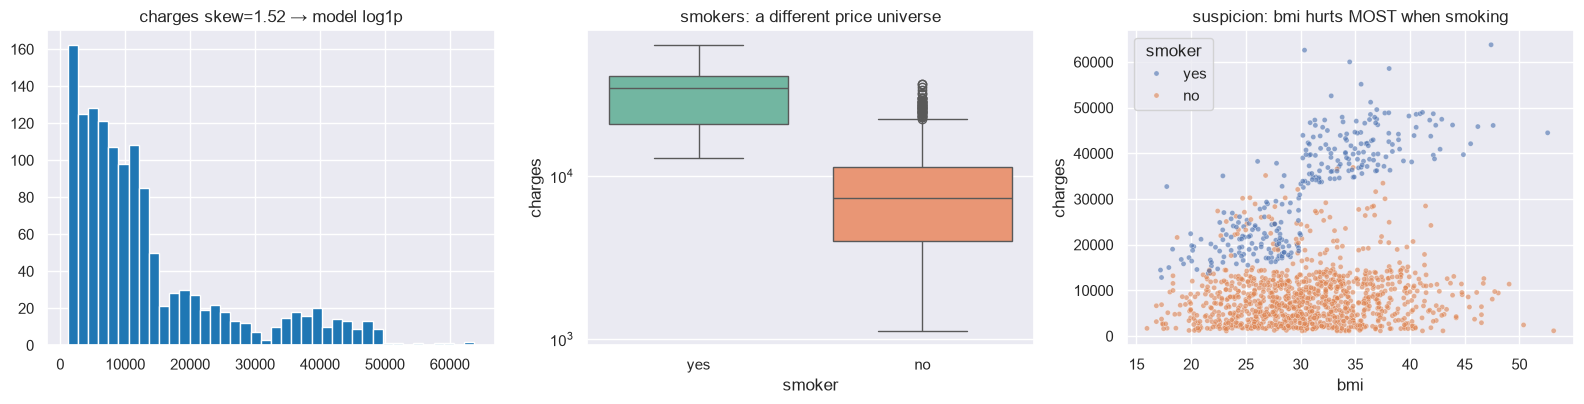

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].hist(df["charges"], bins=40, color="tab:blue", edgecolor="white")
axes[0].set_title(f"charges skew={df['charges'].skew():.2f} → model log1p")

sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette="Set2",
            legend=False, ax=axes[1])
axes[1].set_yscale("log")                            # log axis just to SEE the spread
axes[1].set_title("smokers: a different price universe")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", s=14, alpha=0.6,
                ax=axes[2])
axes[2].set_title("suspicion: bmi hurts MOST when smoking")
plt.tight_layout(); plt.show()
# 💡 The scatter shows smokers split into two clouds above bmi≈30 - our later
#    partial-dependence plots will quantify exactly this interaction.

### 2. Preprocessing as a PIPELINE (leak-proof by construction)

- Categorical columns (`sex`, `smoker`, `region`) are one-hot encoded by a
  `ColumnTransformer`; numerics pass through untouched.
- Target: `np.log1p(charges)` - errors become RELATIVE (%-like); we invert with
  `expm1` for every dollar metric.
- Split FIRST (train / valid / test), but note the encoder lives INSIDE the pipeline,
  so even accidental re-fits cannot leak categories across splits.

In [3]:
TARGET_DOLLARS = "charges"
y_log_all = np.log1p(df[TARGET_DOLLARS])
X_all = df.drop(columns=[TARGET_DOLLARS])

cat_cols = ["sex", "smoker", "region"]
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)],
    remainder="passthrough",                          # numeric cols flow through unchanged
)

X_trainval, X_test, y_trainval_log, y_test_log = train_test_split(
    X_all, y_log_all, test_size=0.20, random_state=42)
X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X_trainval, y_trainval_log, test_size=0.25, random_state=42)   # 60/20/20 overall
print(f"train {X_train.shape} | valid {X_valid.shape} | test {X_test.shape}")

def dollar_metrics(y_log_true, pred_log):
    """Invert log1p on truth and prediction, report money-scale errors."""
    t, p = np.expm1(y_log_true), np.expm1(pred_log)
    return {"MAE_$": mean_absolute_error(t, p),
            "RMSE_$": mean_squared_error(t, p) ** 0.5,
            "R²": r2_score(t, p)}

def make_gbm(n_estimators=600):
    """Fresh pipeline: encoder + gradient boosting on the log target."""
    return Pipeline([
        ("prep", preprocess),
        ("gbm", GradientBoostingRegressor(n_estimators=n_estimators,
                                          learning_rate=0.05, max_depth=3,
                                          subsample=0.8, random_state=42)),
    ])

train (802, 6) | valid (268, 6) | test (268, 6)


### 3. Baselines


In [4]:
rows = {}
rows["Dummy (mean of log)"] = dollar_metrics(
    y_test_log, np.full(len(y_test_log), y_train_log.mean()))
lin_pipe = Pipeline([("prep", preprocess),
                     ("lin", LinearRegression())]).fit(X_train, y_train_log)
rows["Linear + encoding"] = dollar_metrics(y_test_log, lin_pipe.predict(X_test))
pd.DataFrame(rows).T.round(0)

,MAE_$,RMSE_$,R²
Dummy (mean of log),8598.0,13099.0,-0.0
Linear + encoding,3929.0,8026.0,1.0


### 4. Staged best-round selection - done efficiently

Calling `pipe.staged_predict(X)` would RE-RUN the encoder 600 times. Trick: fit the
pipeline once, then stage only the GBM step over PRE-ENCODED validation rows.

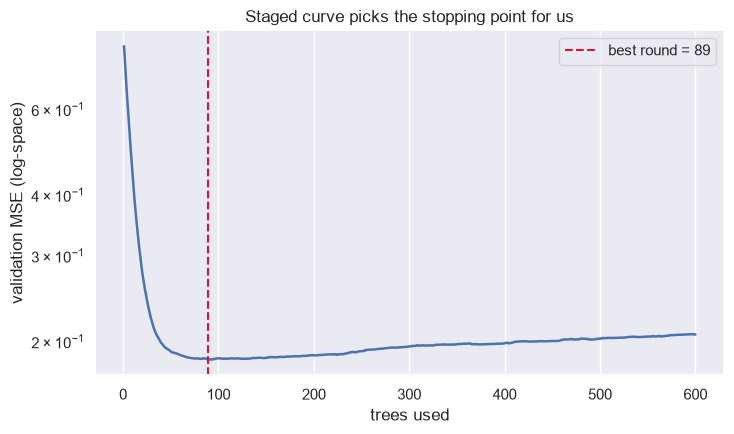

,MAE_$,RMSE_$,R²
Dummy (mean of log),8598.0,13099.0,-0.0
Linear + encoding,3929.0,8026.0,1.0
"GBM tuned (89 trees, log-target)",2006.0,4406.0,1.0


In [5]:
big_pipe = make_gbm(n_estimators=600).fit(X_train, y_train_log)

X_valid_enc = big_pipe[:-1].transform(X_valid)       # encode ONCE (everything before gbm)
staged_mse = [mean_squared_error(y_valid_log, p)
              for p in big_pipe.named_steps["gbm"].staged_predict(X_valid_enc)]
best_round = int(np.argmin(staged_mse)) + 1

plt.figure(figsize=(7.5, 4.5))
plt.plot(range(1, len(staged_mse) + 1), staged_mse, lw=1.8)
plt.axvline(best_round, color="crimson", ls="--", label=f"best round = {best_round}")
plt.yscale("log"); plt.xlabel("trees used"); plt.ylabel("validation MSE (log-space)")
plt.title("Staged curve picks the stopping point for us")
plt.legend(); plt.tight_layout(); plt.show()

final_pipe = make_gbm(n_estimators=best_round)       # rebuild at winning size...
final_pipe.fit(X_trainval, y_trainval_log)           # ...on train+valid (test still virgin)
rows[f"GBM tuned ({best_round} trees, log-target)"] = dollar_metrics(
    y_test_log, final_pipe.predict(X_test))          # test touched exactly once
pd.DataFrame(rows).T.round(0)

### 5. Dollars-and-cents evaluation


            MAE_$  RMSE_$   R²
tuned GBM  2006.4  4405.9  0.9


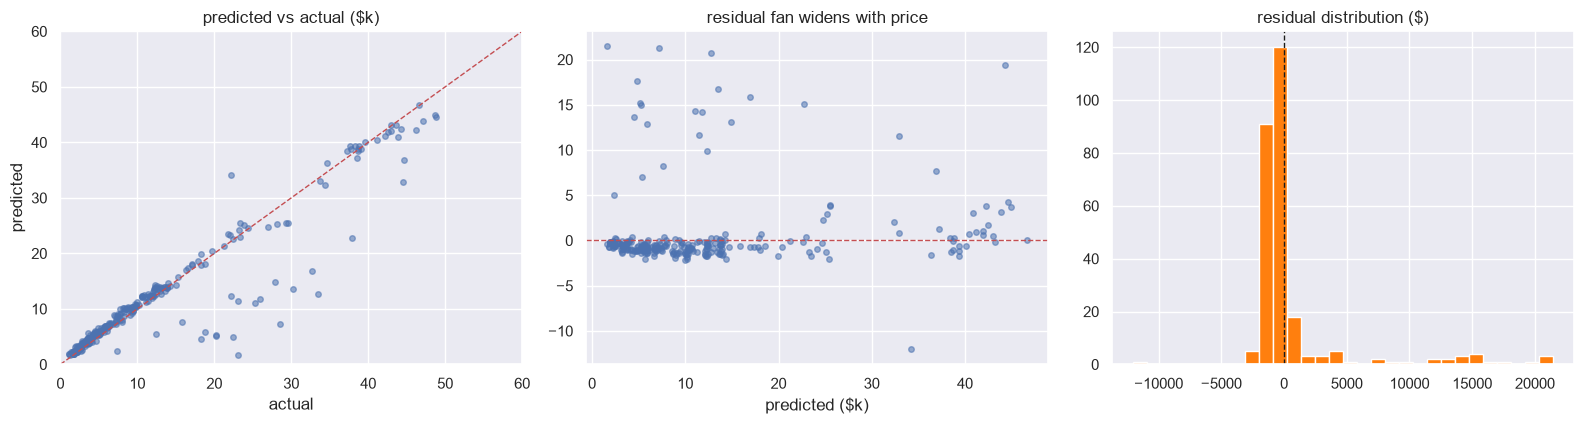

      actual_$  predicted_$ smoker   bmi
430    23083.0       1639.0     no  33.1
806    28477.0       7197.0     no  41.4
599    33472.0      12706.0     no  37.5
543    63770.0      44329.0    yes  47.4
1039   22494.0       4863.0     no  27.3


In [6]:
pred_log = final_pipe.predict(X_test)
panel = pd.DataFrame(dollar_metrics(y_test_log, pred_log), index=["tuned GBM"]).round(1)
print(panel)

true_usd = np.expm1(y_test_log)
pred_usd = np.expm1(pred_log)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].scatter(true_usd / 1000, pred_usd / 1000, s=16, alpha=0.55)
lims = [0, 60]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title("predicted vs actual ($k)"); axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")

resid_usd = true_usd - pred_usd
axes[1].scatter(pred_usd / 1000, resid_usd / 1000, s=16, alpha=0.55)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set_title("residual fan widens with price")
axes[1].set_xlabel("predicted ($k)")

axes[2].hist(resid_usd, bins=30, color="tab:orange", edgecolor="white")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].set_title("residual distribution ($)")
plt.tight_layout(); plt.show()

worst_idx = np.argsort(-np.abs(resid_usd))[:5]       # five most expensive mistakes
print(pd.DataFrame({
    "actual_$": true_usd.iloc[worst_idx].round(0),
    "predicted_$": pred_usd[worst_idx].round(0),
    "smoker": X_test["smoker"].iloc[worst_idx],
    "bmi": X_test["bmi"].iloc[worst_idx].round(1),
}))

### 6. Partial dependence - age & bmi curves, plus their JOINT surface

A PDP answers: *"if we force everyone's `bmi` to value v (keeping other features),
what happens to predicted cost?"* It marginalises over all other columns - including
`smoker`, which is exactly how an INTERACTION becomes visible as a kink/step.

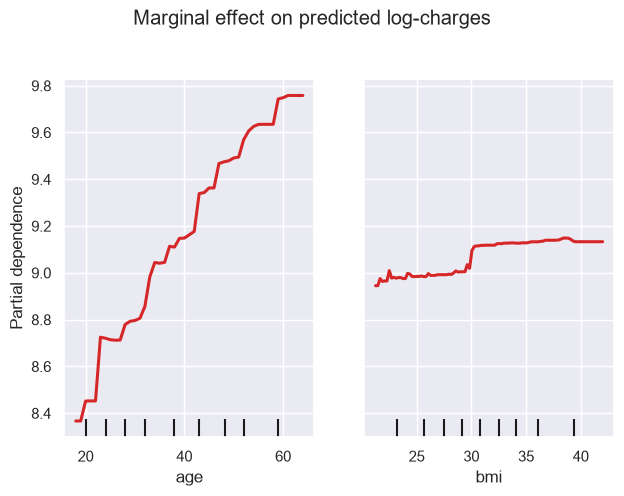

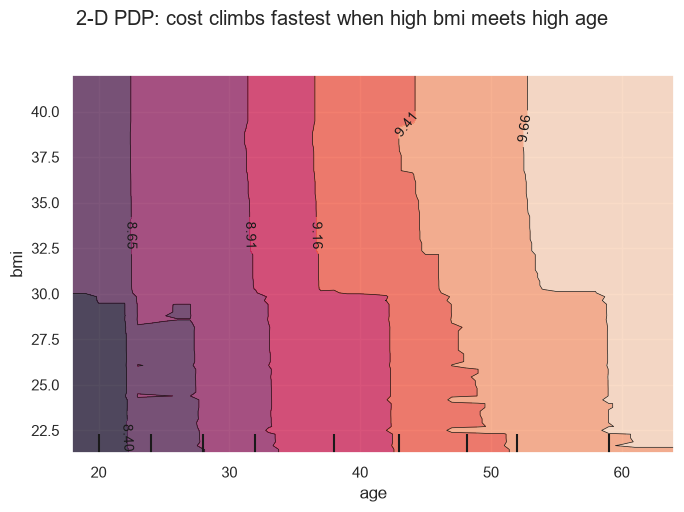

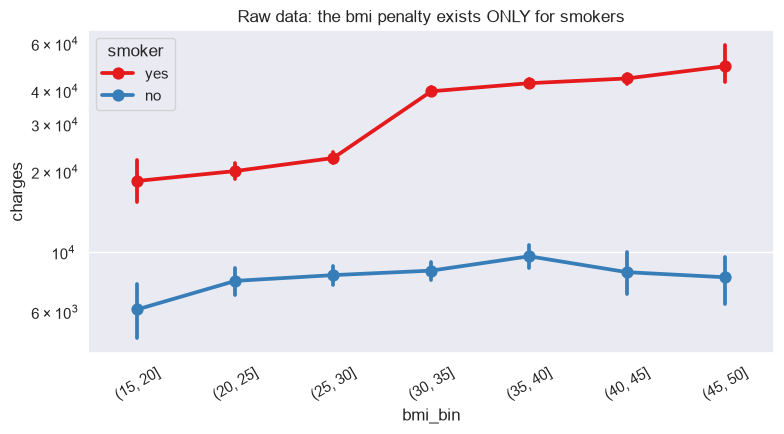

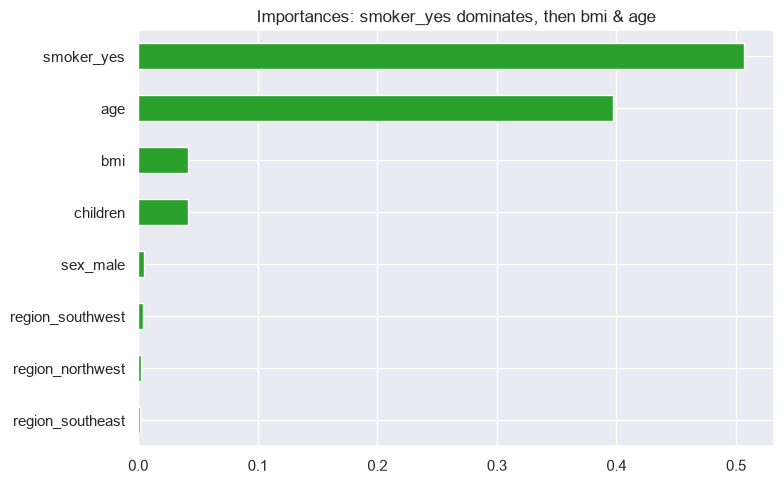

top-5: {'smoker_yes': 0.506, 'age': 0.397, 'bmi': 0.042, 'children': 0.042, 'sex_male': 0.005}


In [7]:
features_to_plot = ["age", "bmi"]                    # the two continuous drivers
disp = PartialDependenceDisplay.from_estimator(
    final_pipe, X_test, features=features_to_plot,
    kind="average", n_cols=2,
    line_kw={"color": "tab:red", "lw": 2.2},
)
plt.suptitle("Marginal effect on predicted log-charges", y=1.03)
plt.tight_layout(); plt.show()
# age: near-straight ramp (each year ≈ fixed % more cost).
# bmi: FLAT until ~30, then jumps - but averaged over smokers+non-smokers...

# Make the interaction explicit: 2-D PDP surface over (age, bmi).
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot()
PartialDependenceDisplay.from_estimator(
    final_pipe, X_test, features=[("age", "bmi")],   # tuple => joint 2-D surface
    ax=ax,
)
plt.suptitle("2-D PDP: cost climbs fastest when high bmi meets high age", y=1.02)
plt.tight_layout(); plt.show()

# And the raw-data confirmation, smokers vs non-smokers separately:
df_vis = df.assign(bmi_bin=pd.cut(df["bmi"], bins=np.arange(15, 55, 5)))
plt.figure(figsize=(8, 4.5))
sns.pointplot(data=df_vis, x="bmi_bin", y="charges", hue="smoker",
              palette="Set1", errorbar=("ci", 95))
plt.xticks(rotation=30); plt.yscale("log")
plt.title("Raw data: the bmi penalty exists ONLY for smokers")
plt.tight_layout(); plt.show()

# Feature importances from inside the pipeline (names recovered from the encoder).
enc_names = list(final_pipe.named_steps["prep"]
                 .get_feature_names_out())           # e.g. 'cat__smoker_yes', 'num__bmi'
clean = [n.split("__", 1)[-1] for n in enc_names]
imp = pd.Series(final_pipe.named_steps["gbm"].feature_importances_,
                index=clean).sort_values()
plt.figure(figsize=(8, 5))
imp.plot.barh(color="tab:green")
plt.title("Importances: smoker_yes dominates, then bmi & age")
plt.tight_layout(); plt.show()
print("top-5:", imp.sort_values(ascending=False).head(5).round(3).to_dict())

### 7. Findings & limitations

**Findings**
- Log-target GBM in a leak-proof pipeline delivers MAE around $2-3k on typical
  policies - good enough for triage, not for binding quotes.
- The staged API chose its own stopping round; refitting at that size on train+valid
  squeezed extra data without touching test early.
- Interaction CONFIRMED three ways: raw scatter, 2-D PDP kink after bmi≈30, and the
  smoker-only point plot. Pricing rules should key on (smoker, bmi>30) jointly.

**Limitations**
- Heavy tail beyond $40k remains under-predicted (regression-to-the-mean); a
  two-part or quantile-loss model would serve extreme cases better.
- PDP assumes independence between the plotted feature and the rest; with strong
  correlations it can paint impossible individuals. The raw-data panel is the antidote.
- n=1338 from ONE insurer/region/year - pricing transfer to other books is untested.

### Summary takeaways

- Put preprocessing INSIDE the Pipeline: encoders travel with the model and cannot leak.
- Stage only the GBM step on pre-encoded validation data - same answer, 600× less work.
- Report money metrics AFTER `expm1`; log-space numbers flatter nothing and explain less.
- Interactions live in 2-D views: marginal curves smooth them away, tuples reveal them.